<a href="https://colab.research.google.com/github/rapsandhani/DataScience_240401010174_AbdullahRapsandani/blob/main/Pertemuan4_AbdullahRapsandani_240401010174.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Nama Lengkap  : Abdullah Rapsandani
#### NIM           : 240401010174
#### Kelas         : IF403


# **Sesi 4 – Statistika Dasar & Analisis Data**

# STEP 1 — Load & Inspect Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


df = sns.load_dataset('iris')

print(' SHAPE DATASET ')
print('Shape:', df.shape)
print('\n TIPE DATA (DTYPES) ')
print(df.dtypes)
print('\n 5 DATA PERTAMA (HEAD) ')
print(df.head())
print('\n STATISTIK DESKRIPTIF RINGKAS ')
print(df.describe().round(3))

 SHAPE DATASET 
Shape: (150, 5)

 TIPE DATA (DTYPES) 
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

 5 DATA PERTAMA (HEAD) 
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

 STATISTIK DESKRIPTIF RINGKAS 
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%        

# STEP 2 — Statistik Deskriptif Lengkap

In [ ]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n Statistik Deskriptif: {col_name} ')
    print(f' Mean      : {col.mean():.3f}')
    print(f' Median    : {col.median():.3f}')
    print(f' Std Dev   : {col.std():.3f}')
    print(f' Varians   : {col.var():.3f}')
    print(f' Skewness  : {col.skew():.3f}')
    print(f' Kurtosis  : {col.kurt():.3f}')

# STEP 3 — Analisis Distribusi (Histogram + KDE)

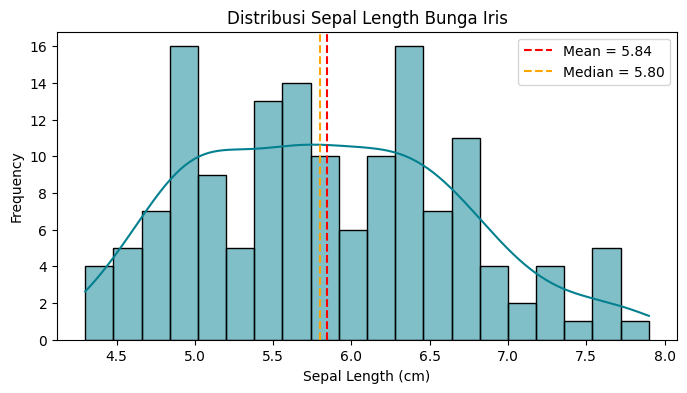

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

# Menambahkan garis Vertikal untuk Mean dan Median
mean_val = df['sepal_length'].mean()
median_val = df['sepal_length'].median()

ax.axvline(mean_val, color='red', linestyle='--', label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, color='orange', linestyle='--', label=f"Median = {median_val:.2f}")

ax.set_title('Distribusi Sepal Length Bunga Iris')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

# STEP 4 — Boxplot per Spesies

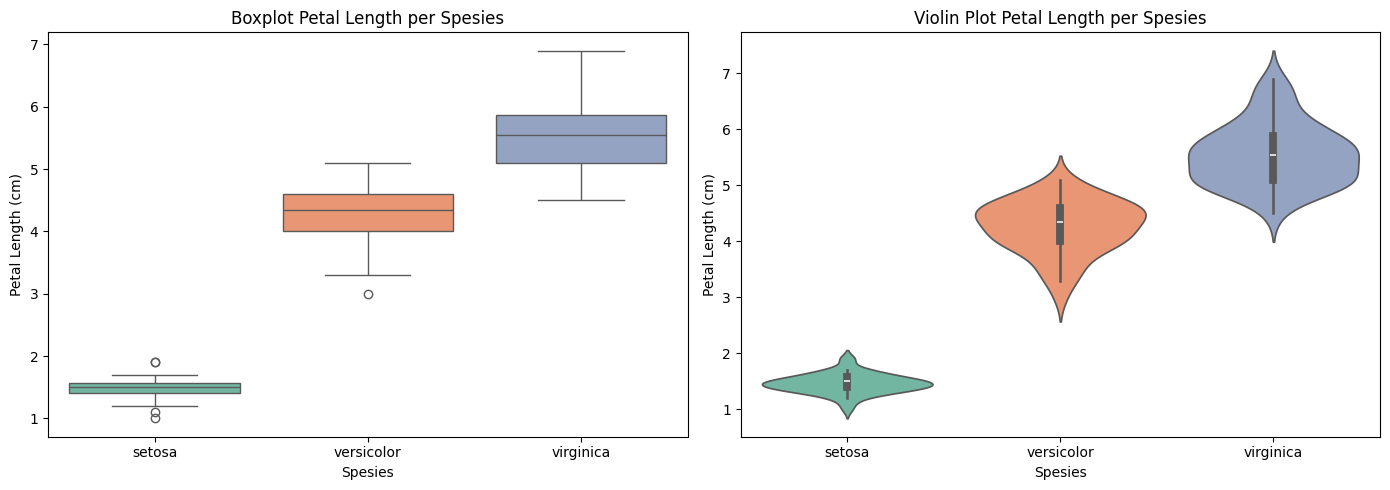

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot (Mnambahkan hue dan legend=False)
sns.boxplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies')
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Petal Length (cm)')

# Violin Plot (Menambahkan hue dan legend=False)
sns.violinplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', inner='box', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies')
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

# STEP 5 — Matriks Korelasi Pearson

In [ ]:
# Menghitung matriks korelasi pearson (drop kolom non-numerik 'species')
corr = df.drop('species', axis=1).corr(method='pearson')
print(" MATRIKS KORELASI PEARSON ")
print(corr.round(3))
print("\n" + "-"*32)

# Menggunakan mask untuk mencari pasangan korelasi tertinggi dan terendah
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

# Cari korelasi tertinggi
max_pair = corr_masked.stack().idxmax()
max_val = corr_masked.stack().max()

# Cari korelasi terendah (paling mendekati 0 atau negatif terkuat)
min_pair = corr_masked.stack().idxmin()
min_val = corr_masked.stack().min()

print(f'Korelasi Tertinggi : {max_pair} = {max_val:.3f}')
print(f'Korelasi Terendah  : {min_pair} = {min_val:.3f}')


 MATRIKS KORELASI PEARSON 
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

--------------------------------
Korelasi Tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi Terendah  : ('petal_length', 'sepal_width') = -0.428


# STEP 6 — Scatter Plot & Heatmap

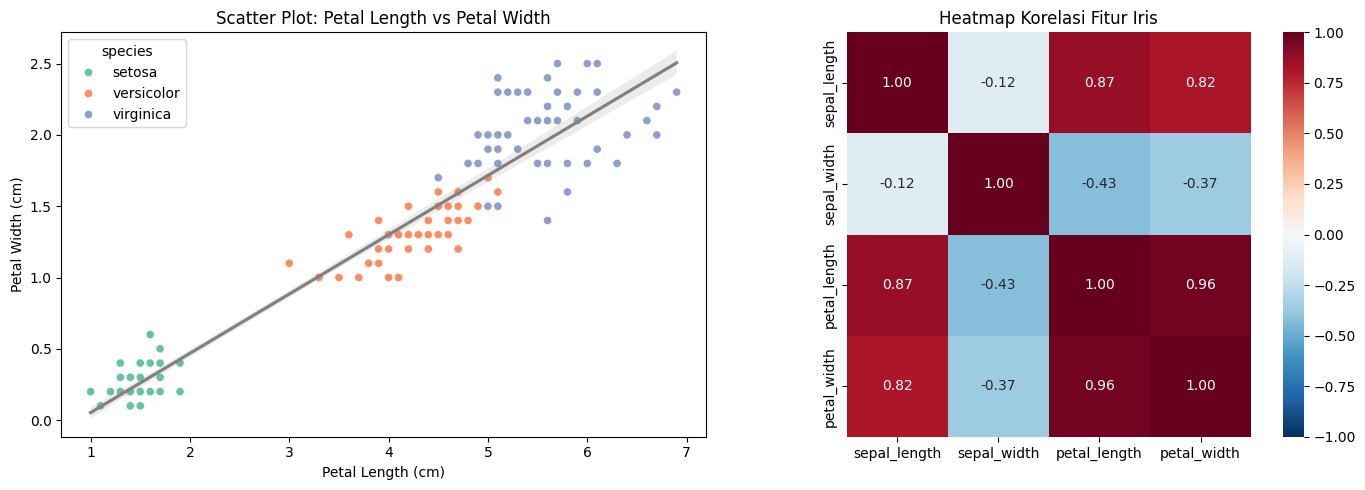

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot pasangan paling berkorelasi (petal_length vs petal_width)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Heatmap Korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi Fitur Iris')

plt.tight_layout()
plt.show()

Secara umum, ukuran kelopak (Petal) terbukti lebih efektif untuk klasifikasi spesies Iris karena pola keterkaitannya stabil dan mampu memisahkan kelompok dengan lebih tegas daripada ukuran sepal.

#Kesimpulan
------

Pada pertemuan ini saya mempelajari statistik deskriptif menggunakan Dataset Iris. Analisis dilakukan dengan menghitung mean, median, modus, varians, standar deviasi, serta nilai minimum dan maksimum.

Hasil analisis menunjukkan bahwa setiap spesies bunga Iris memiliki karakteristik yang berbeda, terutama pada ukuran petalnya. Statistik deskriptif membantu memahami pola data sebelum dilakukan visualisasi atau pemodelan Machine Learning. Pertanyaan yang muncul adalah bagaimana statistik ini dapat digunakan untuk membantu proses klasifikasi data.